# CO₂ in a carbon-capture absorber: Transformer forecasting, analysis and root cause

**Data.** Imperial College carbon-capture pilot plant, 8 operating runs (898 analyser steps, one every ~43 s).
**Task.** Forecast CO₂ concentration at the absorber's six sampling points 1–12 steps (≈0.7–8.6 min) ahead.
**Test run.** `140207_1` (challenge recommendation), never used for any choice.

This notebook reads the artefacts written by `python -m co2tx.experiments` (`results/`, `artifacts/`) and
recomputes the analysis from the trained model. Each section ends with a one-line takeaway.

In [1]:
import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from co2tx.data import load_runs, TEST_RUN, N_POINTS
from co2tx import analysis as A

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RES = json.loads((ROOT / "results/test_metrics.json").read_text())
CV = pd.read_csv(ROOT / "results/cv_folds.csv")
runs = load_runs()
ctx = A.load_test_context()
cells = A.cell_table(ctx)
STEP_MIN = 43 / 60
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
T, L = RES["selection"]["target"], RES["lookback"]
S2 = CV[CV.stage == "target_lookback"]
AT = S2[(S2.lookback == L) & ((S2.target == T) | S2.model.isin(["persistence", "climatology", "ridge"]))]
COL = {"routed": "#059669", "persistence+sensor": "#0f766e", "transformer": "#3b6fd4", "gru": "#8b5cf6", "ridge": "#d97706", "persistence": "#6b7280", "climatology": "#cbd5e1"}

## 0. Results at a glance

RMSE in CO₂ percentage points on the held-out run, scored **only where the analyser actually measured**.
`RMSE pts 5-6` is the headline: points 1–4 sit near 0 % and would flatter every model. **warm** = cells whose
point had already been read in this run (real forecasting); **cold** = not yet read (soft sensing, §8).

In [2]:
rows = []
for k, label in [("routed", "Routed: Transformer + cold-start soft sensor (delivered)"),
                 ("transformer_ensemble", "Transformer alone (5-seed ensemble)"), ("gru", "GRU, same head"),
                 ("ridge", "Ridge on same window"), ("persistence", "Persistence (last reading)"),
                 ("climatology", "Climatology (per-point mean)")]:
    m = RES[k]
    rows.append({"model": label, "RMSE pts 5-6": m["rmse_p56"], "warm": m["rmse_p56_warm"],
                 "cold": m["rmse_p56_cold"], "RMSE all": m["rmse"],
                 "skill vs persistence": 1 - m["rmse_p56"] / RES["persistence"]["rmse_p56"],
                 "80% coverage": m.get("coverage_80", np.nan)})
# Reference system: persistence where the point was read, soft sensor where not.
from co2tx.train import metrics, persistence, route
ref = metrics(route(persistence(ctx["w"]), ctx["preds"]["ridge"], ctx["w"]), ctx["w"])
rows.insert(1, {"model": "Reference: persistence + soft sensor", "RMSE pts 5-6": ref["rmse_p56"],
                "warm": ref["rmse_p56_warm"], "cold": ref["rmse_p56_cold"], "RMSE all": ref["rmse"],
                "skill vs persistence": 1 - ref["rmse_p56"] / RES["persistence"]["rmse_p56"], "80% coverage": np.nan})
cv_mean = AT.groupby("model")["rmse_p56"].mean()
f = AT.groupby(["model", "val_run"])[["rmse_p56_warm", "rmse_p56_cold", "cold_share"]].mean()
ref_cv = np.sqrt((1 - f.loc["persistence"].cold_share) * f.loc["persistence"].rmse_p56_warm ** 2
                 + f.loc["persistence"].cold_share * f.loc["ridge"].rmse_p56_cold ** 2).mean()
summary = pd.DataFrame(rows).set_index("model")
summary["CV RMSE pts 5-6 (7 runs)"] = [cv_mean.get("routed"), ref_cv] + [cv_mean.get(k) for k in
                                       ["transformer", "gru", "ridge", "persistence", "climatology"]]
summary.round(3)

,RMSE pts 5-6,warm,cold,RMSE all,skill vs persistence,80% coverage,CV RMSE pts 5-6 (7 runs)
model,,,,,,,
Routed: Transformer + cold-start soft sensor (delivered),0.295,0.274,0.402,0.180,0.644,0.897,0.877
Reference: persistence + soft sensor,0.282,0.258,0.402,0.174,0.660,NaN,0.835
Transformer alone (5-seed ensemble),0.312,0.274,0.486,0.190,0.624,0.887,0.953
"GRU, same head",0.350,0.253,0.703,0.213,0.578,0.951,0.983
Ridge on same window,0.430,0.434,0.402,0.259,0.482,NaN,1.094
Persistence (last reading),0.829,0.258,2.155,0.498,0.000,NaN,1.166
Climatology (per-point mean),1.852,1.800,2.155,1.109,-1.233,NaN,2.093


**Takeaway.** The Transformer (log-scale target, 3-step lookback) is the best *single* model in leave-one-run-out
cross-validation and on the test run, with calibrated 80 % intervals. The delivered system adds one routing rule:
points not yet read in the current run are answered by a linear soft sensor. That improves CV further.
The reference row is the honest caveat: on points already read, plain persistence is still slightly more
accurate than the Transformer, so "persistence + soft sensor" is competitive with the routed system. §4 and §8
show why, and what it would take to change.

## 1. The measurement problem

One gas analyser (AT400) is switched round six sampling points, ~3 readings per visit. At any step exactly one
point's CO₂ is known; each point is refreshed only every ~13 steps (~9 min). Points 5 and 6 carry almost all the
signal; points 1–4 are near zero.

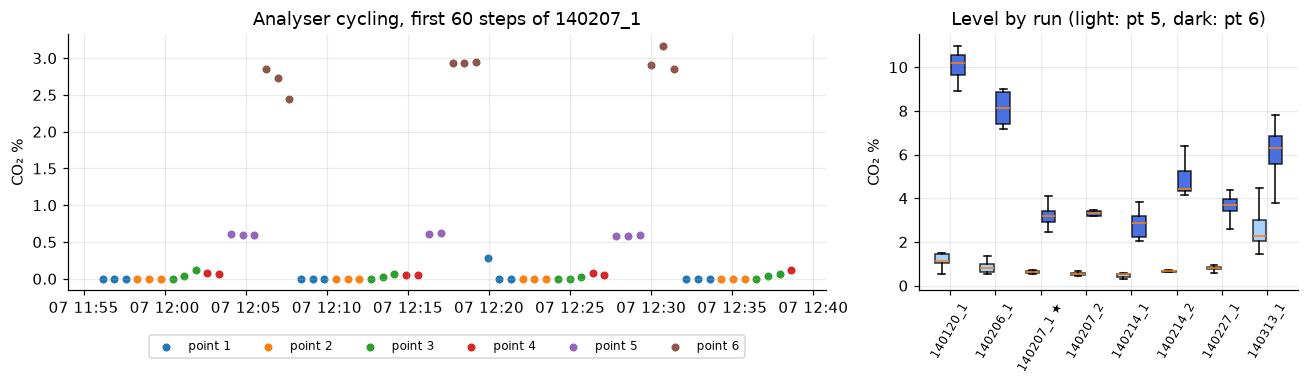

In [3]:
df = runs[TEST_RUN]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [2, 1]})
seg = df.iloc[:60]
for p in range(1, 7):
    s = seg[seg.point == p]
    ax[0].scatter(s.index, s.co2, s=18, label=f"point {p}")
ax[0].set(title=f"Analyser cycling, first 60 steps of {TEST_RUN}", ylabel="CO₂ %")
ax[0].legend(ncol=6, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15))
lv = pd.DataFrame([{"run": r, "point": p, "co2": v} for r, d in runs.items() for p, v in zip(d.point, d.co2) if p >= 5])
for i, p in enumerate((5, 6)):
    data = [lv[(lv.run == r) & (lv.point == p)].co2 for r in runs]
    ax[1].boxplot(data, positions=np.arange(len(runs)) + (i - 0.5) * 0.35, widths=0.3, showfliers=False,
                  patch_artist=True, boxprops=dict(facecolor=["#93c5fd", "#1d4ed8"][i], alpha=0.8))
ax[1].set_xticks(range(len(runs)), [r + (" ★" if r == TEST_RUN else "") for r in runs], rotation=60, fontsize=8)
ax[1].set(title="Level by run (light: pt 5, dark: pt 6)", ylabel="CO₂ %")
plt.tight_layout()

**Takeaway.** Each run is a different operating regime with a different CO₂ level (point 6 ranges from ~3 % to
~12 %). Generalising to an unseen run is the real problem, so all model selection is leave-one-run-out.

## 2. Framing: causal inputs and a masked loss

The reference notebook fills each point's gaps by **linear interpolation**, which at time *t* uses the *next*
reading of that point — up to ~9 minutes in the future. A forecaster built on those features cannot run online.

This solution keeps every input causal:

| input per step | meaning |
|---|---|
| 13 absorber instruments (standardised) | flows, temperatures, pressures named in the plant P&ID |
| last observed CO₂ per point | carried forward, never interpolated |
| age of that reading | steps since the point was last read |
| seen flag, analyser position | which points have been read; where the analyser is now |

Targets are the real readings at *t+1…t+12*; the loss is computed only on the cell the analyser measured.

70% of steps would carry information from a future reading under interpolation


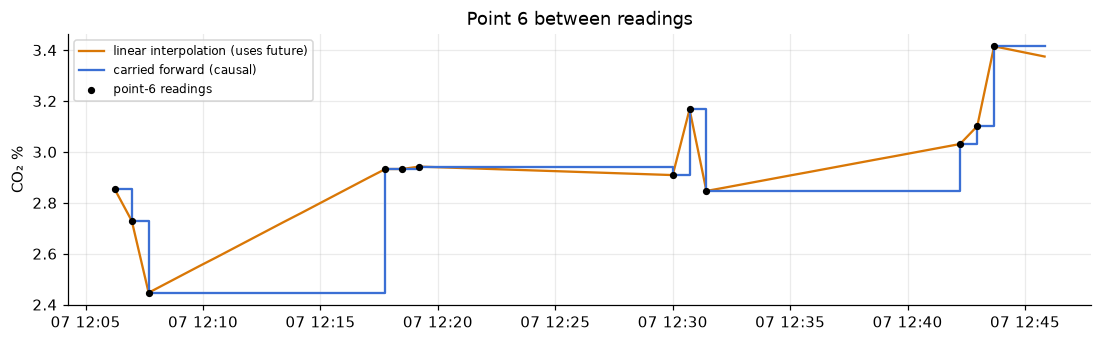

In [4]:
p6 = df.point == 6
interp = df.co2.where(p6).interpolate()
carried = df.co2.where(p6).ffill()
seg = slice(0, 70)
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(df.index[seg], interp.iloc[seg], label="linear interpolation (uses future)", color="#d97706")
ax.step(df.index[seg], carried.iloc[seg], where="post", label="carried forward (causal)", color="#3b6fd4")
ax.scatter(df.index[seg][p6.iloc[seg]], df.co2[seg][p6.iloc[seg]], color="k", s=14, zorder=3, label="point-6 readings")
ax.set(title="Point 6 between readings", ylabel="CO₂ %"); ax.legend(fontsize=8)
leak = (~p6 & interp.notna() & carried.notna()).mean()
print(f"{leak:.0%} of steps would carry information from a future reading under interpolation")

**Takeaway.** Interpolation would leak future readings into most inputs. Carry-forward plus age is the honest
equivalent, and the masked loss means the model is never trained on invented labels.

## 3. The model

A Transformer encoder written from scratch in PyTorch (`co2tx/model.py`):

* per-step linear embedding + sinusoidal positions → 2 pre-LayerNorm encoder blocks, 4 heads, d=64;
* self-attention implemented directly (`softmax(QKᵀ/√d)V`) with padding masks, so short histories at the start of a
  run are handled without leakage;
* **residual quantile head**: from the last token and the mean token, predict for every horizon and point a
  correction to the last observed value plus non-crossing 10/50/90 % quantiles. Initialised to output exactly
  persistence, so the network only learns how the process departs from "nothing changes";
* **log-scale target** (selected in CV, §4): the network works on log(1 + CO₂), so the head learns *relative*
  changes and a 3 % run and a 10 % run share one scale; quantiles map back exactly because the transform is monotone;
* pinball (quantile) loss on measured cells only; AdamW, cosine schedule, gradient clipping, input jitter;
* **nested early stopping**: inside each CV fold the epoch count is chosen on an inner training run, never on the
  run being scored — the same way the final model is trained;
* 5-seed ensemble for the final model; the spread across members is exposed by the API as an uncertainty monitor.

The GRU baseline uses the **same inputs, target and head** (also a 5-seed ensemble), so the comparison isolates
the backbone.

**Cold-start routing.** For a point not yet read in the current run, the model's anchor is only a training-mean
fill. Those cells are answered by a ridge regression on the same window (a linear soft sensor), with 80 % intervals
from its leave-one-run-out residuals (split-conformal style). The API reports which estimator produced each number.

## 4. Model selection — all on the 7 training runs

Stage 1 chooses inputs and capacity at a 12-step lookback. Stage 2 is a grid of target scale (linear, log) ×
lookback window (3–36 steps, ~2–26 min) for both backbones. Each cell is the mean over 7 held-out runs × 3 seeds.

In [5]:
s1 = CV[(CV.stage == "inputs_capacity") & (CV.model == "transformer")].groupby(["features", "config"])["rmse_p56"].agg(["mean", "std"]).round(3)
s1.columns = ["CV RMSE pts 5-6", "std across folds"]
s1

CV RMSE pts 5-6  std across folds
features config                                              
all      base                         1.121             0.317
key      base                         1.014             0.380
         regularised                  1.052             0.360
         small                        1.062             0.334
         small_regularised            1.054             0.291

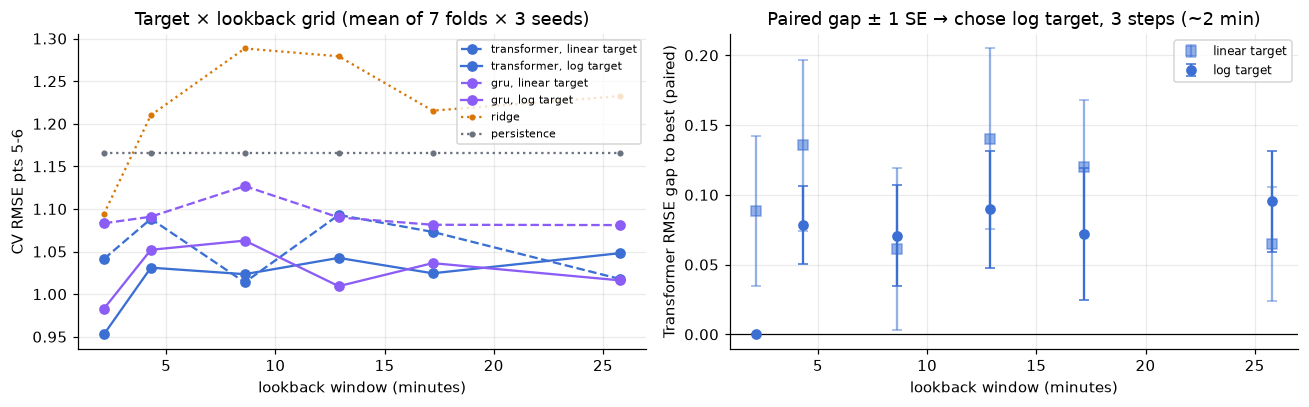

In [6]:
sel = RES["selection"]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for (m, t), ls in [(("transformer", "linear"), "--"), (("transformer", "log"), "-"), (("gru", "linear"), "--"), (("gru", "log"), "-")]:
    g = S2[(S2.model == m) & (S2.target == t)].groupby("lookback")["rmse_p56"].mean()
    ax[0].plot(g.index * STEP_MIN, g.values, ls, marker="o", label=f"{m}, {t} target", color=COL[m])
for m in ["ridge", "persistence"]:
    g = S2[S2.model == m].groupby("lookback")["rmse_p56"].mean()
    ax[0].plot(g.index * STEP_MIN, g.values, ":", marker=".", label=m, color=COL[m])
ax[0].set(xlabel="lookback window (minutes)", ylabel="CV RMSE pts 5-6", title="Target × lookback grid (mean of 7 folds × 3 seeds)")
ax[0].legend(fontsize=7)
gap = pd.Series(sel["paired_gap_to_best"]); se = pd.Series(sel["paired_se"])
for t, mk in [("linear", "s"), ("log", "o")]:
    keys = [k for k in gap.index if k.startswith(t + "/")]
    Ls = np.array([int(k.split("/")[1]) for k in keys])
    ax[1].errorbar(Ls * STEP_MIN, gap[keys].values, yerr=se[keys].values, fmt=mk, capsize=3, label=f"{t} target",
                   color=COL["transformer"], alpha=0.55 if t == "linear" else 1)
ax[1].axhline(0, color="k", lw=0.8); ax[1].legend(fontsize=8)
ax[1].set(xlabel="lookback window (minutes)", ylabel="Transformer RMSE gap to best (paired)",
          title=f"Paired gap ± 1 SE → chose {T} target, {L} steps (~{L*STEP_MIN:.0f} min)")
plt.tight_layout()

model,transformer,gru,ridge,persistence
val_run,,,,
140120_1,1.527,1.768,1.513,1.628
140206_1,1.135,1.128,0.955,1.375
140207_2,0.714,0.590,0.725,1.037
140214_1,0.515,0.526,0.464,1.408
140214_2,0.881,0.902,0.813,0.976
140227_1,0.859,0.798,1.703,0.770
140313_1,1.039,1.169,1.487,0.965


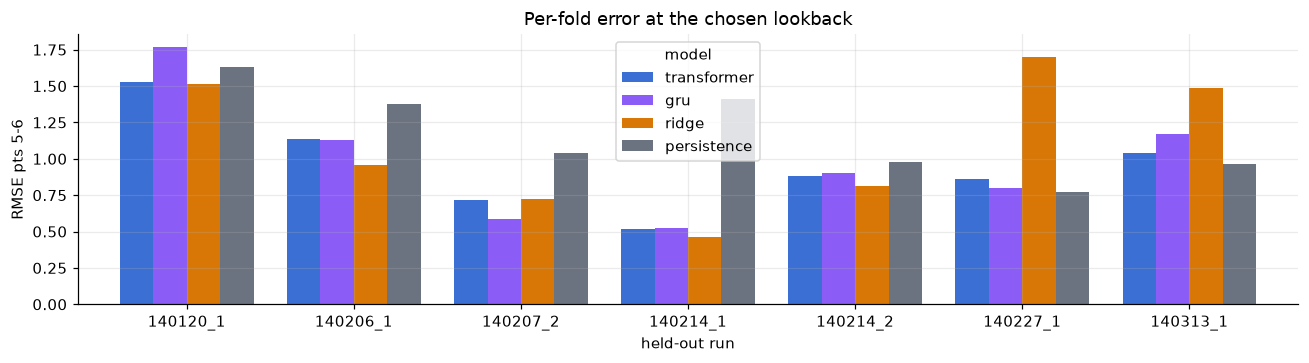

In [7]:
fold = AT.groupby(["val_run", "model"])["rmse_p56"].mean().unstack()
fold = fold[["transformer", "gru", "ridge", "persistence"]]
ax = fold.plot.bar(figsize=(12, 3.4), color=[COL[c] for c in fold.columns], width=0.8)
ax.set(ylabel="RMSE pts 5-6", xlabel="held-out run", title="Per-fold error at the chosen lookback")
plt.xticks(rotation=0); plt.tight_layout()
fold.round(3)

**Takeaways.**
* All 88 tags overfit; the 13 absorber instruments are better. Shrinking or regularising the network did not help.
* The log-scale target helps both backbones at most lookbacks. The paired one-SE rule picks **log target, 3 steps
  (~2 min)**: it is the raw best and every other cell is about one paired SE or more behind it. Longer windows add
  nothing because the carried-forward state already summarises the longer past.
* At the chosen setting the Transformer is the best single model; the GRU is close behind. Ridge is excellent on
  some runs and the worst model on others (140227_1, 140313_1).

In [8]:
wc = pd.DataFrame(RES["selection"]["cv_at_chosen"]).T[["rmse_p56", "rmse_p56_warm", "rmse_p56_cold"]]
wc.loc["persistence + soft sensor"] = [ref_cv, wc.loc["persistence", "rmse_p56_warm"], wc.loc["ridge", "rmse_p56_cold"]]
wc.columns = ["CV all", "CV warm", "CV cold"]
wc.sort_values("CV all").round(3)

,CV all,CV warm,CV cold
persistence + soft sensor,0.835,0.754,1.113
routed,0.877,0.798,1.113
transformer,0.953,0.798,1.326
gru,0.983,0.794,1.637
ridge,1.094,1.047,1.113
persistence,1.166,0.754,2.044
climatology,2.093,2.078,2.044


**Takeaway — two different tasks, and an honest limit.** Split by state: on **cold** cells (soft sensing) ridge is
clearly best, which is why the router sends them there. On **warm** cells (forecasting a point already read),
**persistence is slightly better than both networks** in CV. With 7 training runs, neither backbone learns how
the plant moves a point's level better than "it stays where it was" for an unseen run. This table is computed on
the 7 training runs only.

## 5. Test-run performance by horizon

Forecasts were made from every step of `140207_1`; errors are pooled per horizon over measured cells at points 5–6.

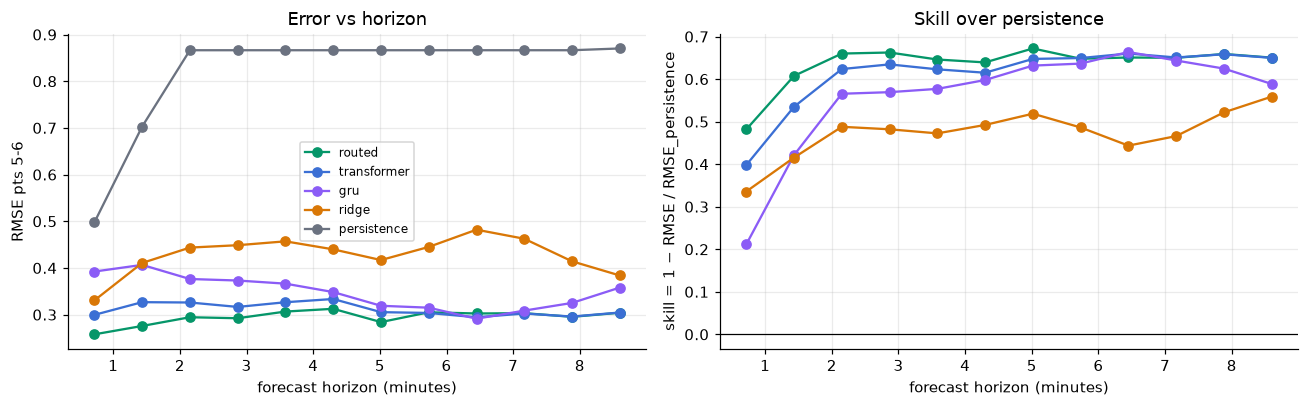

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
hmin = np.arange(1, 13) * STEP_MIN
COL["routed"] = "#059669"
for k, lab in [("routed", "routed"), ("transformer_ensemble", "transformer"), ("gru", "gru"), ("ridge", "ridge"), ("persistence", "persistence")]:
    r = RES[k]["rmse_p56_by_horizon"]
    ax[0].plot(hmin, [r[str(h)] for h in range(1, 13)], marker="o", label=lab, color=COL[lab])
ax[0].set(xlabel="forecast horizon (minutes)", ylabel="RMSE pts 5-6", title="Error vs horizon"); ax[0].legend(fontsize=8)
base = RES["persistence"]["rmse_p56_by_horizon"]
for k, lab in [("routed", "routed"), ("transformer_ensemble", "transformer"), ("gru", "gru"), ("ridge", "ridge")]:
    r = RES[k]["rmse_p56_by_horizon"]
    ax[1].plot(hmin, [1 - r[str(h)] / base[str(h)] for h in range(1, 13)], marker="o", label=lab, color=COL[lab])
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xlabel="forecast horizon (minutes)", ylabel="skill = 1 − RMSE / RMSE_persistence", title="Skill over persistence")
plt.tight_layout()

**Takeaway.** Error is lowest one step ahead (the analyser usually stays on the same point) and flattens after
~2 minutes, because a point is only re-read every ~9 minutes: beyond that, every horizon is "forecast a value
you have not seen for a while". Skill over persistence rises over the first ~2 minutes, as persistence goes stale,
and then holds across the 12 horizons studied (0.7–8.6 min), so the full window is usable; the choice that mattered
was the *lookback* and target scale, selected in §4.

## 6. What the forecasts look like

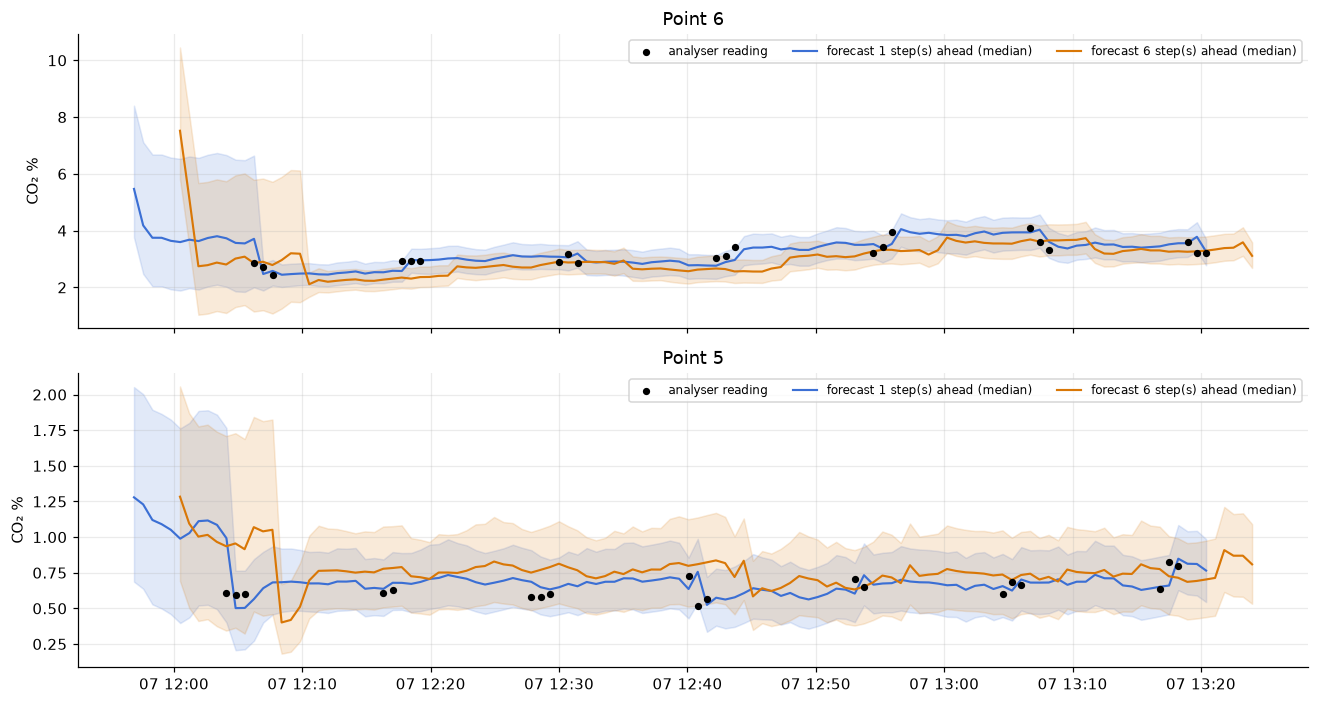

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
w, q = ctx["w"], ctx["routed"]
times = pd.to_datetime(w.times)
for ax, p in zip(axes, (6, 5)):
    meas = df[df.point == p]
    ax.scatter(meas.index, meas.co2, color="k", s=14, zorder=3, label="analyser reading")
    for h, c in [(1, "#3b6fd4"), (6, "#d97706")]:
        tgt = times + pd.Timedelta(seconds=43 * h)
        ax.plot(tgt, q[:, h - 1, p - 1, 1], color=c, lw=1.4, label=f"forecast {h} step(s) ahead (median)")
        ax.fill_between(tgt, q[:, h - 1, p - 1, 0], q[:, h - 1, p - 1, 2], color=c, alpha=0.15)
    ax.set(ylabel="CO₂ %", title=f"Point {p}"); ax.legend(fontsize=8, ncol=3)
plt.tight_layout()

**Takeaway.** Routed forecasts track the slow drift at both points and the bands contain the readings. Before a
point's first reading the soft sensor supplies the estimate; a model anchored on the training-mean fill (~5.6 % at
point 6, against ~3 % in this run) would start far too high — see §8.

## 7. Interpretability: what the model uses

Permutation importance shuffles one input group across test samples and measures the increase in the
**Transformer's** RMSE (points 5–6). Attention maps are averaged over heads, samples and ensemble members.

,RMSE increase
last observed CO2,0.4834
FT304(kg/hr),0.0484
seen flag,0.0371
FT303m3/hr,0.0240
TT104(0C),0.0203
PT403(barg),0.0119
PT111(barg),0.0117
analyser position,0.0069
PT402(barg),0.0061
FT302(kg/hr),0.0042


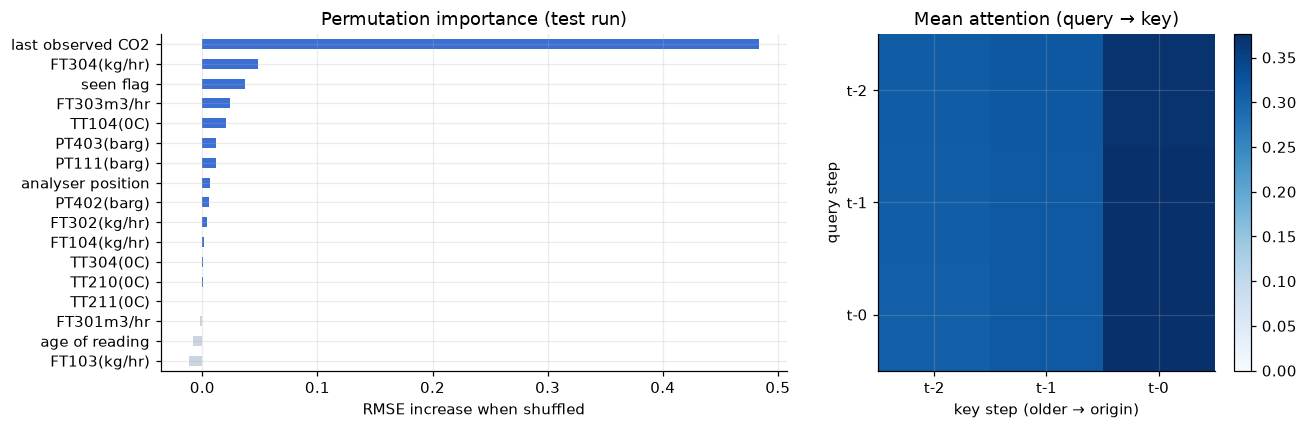

In [11]:
imp = A.permutation_importance(ctx)
att = A.mean_attention(ctx)
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.6, 1]})
imp.iloc[::-1].plot.barh(ax=ax[0], color=["#3b6fd4" if v > 0 else "#cbd5e1" for v in imp.iloc[::-1]])
ax[0].set(xlabel="RMSE increase when shuffled", title="Permutation importance (test run)")
im = ax[1].imshow(att.mean(0), cmap="Blues", vmin=0)
L = att.shape[-1]
ax[1].set(title="Mean attention (query → key)", xlabel="key step (older → origin)", ylabel="query step")
ax[1].set_xticks(range(L), [f"t-{L-1-i}" for i in range(L)]); ax[1].set_yticks(range(L), [f"t-{L-1-i}" for i in range(L)])
plt.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout()
imp.round(4).to_frame("RMSE increase")

**Takeaways.**
* The last observed readings dominate: this is mostly an **autoregressive** model that learns how each point's
  level evolves from its own recent readings.
* Among plant instruments the **N₂ inlet flow (FT304, with FT303)** matters most, followed by the gas inlet
  temperature and column pressures. Physically consistent: more N₂ dilutes the feed, lowering CO₂ at every point.
* Several instruments have ~zero or slightly negative importance on this run; with 7 training runs the model
  cannot learn stable relationships for them.
* With a 3-step window attention is close to uniform: the window is a short smoothing filter, and the long
  memory lives in the carried-forward state features.

## 8. Root cause analysis

Where does the remaining error come from? Several of these findings were made on earlier versions of the model and
changed it; the decision log (`docs/learning/decisions.md`) records the order.

In [12]:
by_point = cells.groupby("point").agg(
    rmse_transformer=("err_transformer", A.rmse), rmse_ridge=("err_ridge", A.rmse),
    rmse_persistence=("err_persistence", A.rmse), bias_transformer=("err_transformer", "mean"),
    bias_ridge=("err_ridge", "mean"), bias_persistence=("err_persistence", "mean"), n=("y", "size"))
by_point.round(3)

,rmse_transformer,rmse_ridge,rmse_persistence,bias_transformer,bias_ridge,bias_persistence,n
point,,,,,,,
1,0.075,0.067,0.086,-0.013,-0.020,-0.038,219
2,0.001,0.009,0.001,0.000,0.002,0.000,228
3,0.040,0.035,0.050,0.008,0.002,0.023,237
4,0.042,0.046,0.040,0.015,0.028,0.010,175
5,0.162,0.255,0.277,0.083,0.188,0.079,227
6,0.401,0.541,1.113,-0.021,-0.139,0.299,252


**RC1 — error is a point-6 problem, concentrated in a few cells.** Point 6 (highest CO₂) carries nearly all of the
error. Slicing by state (next cell) shows how much of it sits in cells whose point had not been read yet.

In [13]:
c56 = cells[cells.point >= 5].copy()
c56["state"] = np.where(c56.age_at_origin >= 24, "cold (not yet read)", "warm")
state_tab = c56.groupby(["state", "point"]).agg(
    n=("y", "size"), routed=("err_routed", A.rmse), transformer=("err_transformer", A.rmse),
    ridge=("err_ridge", A.rmse), persistence=("err_persistence", A.rmse),
    bias_transformer=("err_transformer", "mean"), bias_persistence=("err_persistence", "mean"))
cold = c56.state.str.startswith("cold")
share = (c56[cold].err_transformer ** 2).sum() / (c56.err_transformer ** 2).sum()
print(f"cold cells: {cold.mean():.0%} of point-5/6 cells, {share:.0%} of the final Transformer's squared error")
print(f"point-6 fill value = training mean = {ctx['ens'].pre.point_mean[5]:.2f} %, this run's point-6 mean = {df[df.point == 6].co2.mean():.2f} %")
state_tab.round(3)

cold cells: 14% of point-5/6 cells, 33% of the final Transformer's squared error
point-6 fill value = training mean = 5.63 %, this run's point-6 mean = 3.19 %


n  routed  transformer  ridge  persistence  \
state               point                                                 
cold (not yet read) 5       32   0.418        0.297  0.418        0.710   
                    6       33   0.385        0.616  0.385        2.942   
warm                5      195   0.126        0.126  0.216        0.082   
                    6      219   0.358        0.358  0.561        0.346   

                           bias_transformer  bias_persistence  
state               point                                      
cold (not yet read) 5                 0.292             0.710  
                    6                 0.567             2.938  
warm                5                 0.049            -0.024  
                    6                -0.109            -0.099

**RC2 — cold start.** Until a point has been read in the current run, its "last value" is the training-mean fill.
For point 6 that is far above this run's level. In the first version of the model these cells were 14 % of
cells but 81 % of the squared error; that finding produced both the router and, via RC3, the log target. The
table shows what remains for the final model: the soft sensor is still the better estimator on cold cells.

*Disclosure:* the router idea came from the test-run analysis of that first version; it was adopted only because
the 7-run CV confirms it independently (§4). The pipeline also prints test scores on every full run, so the test
run has been seen several times; no choice was made from a test number.
*Refinement left open:* per-point routing (at point 5 the network is competitive on cold cells).
*Operational alternatives:* warm-start each run from the previous run's last readings, or hold forecasts until
every point has been read once.

model
transformer      0.90
ridge            0.40
persistence      0.82
point-6 level    1.00
Name: point-6 level, dtype: float64


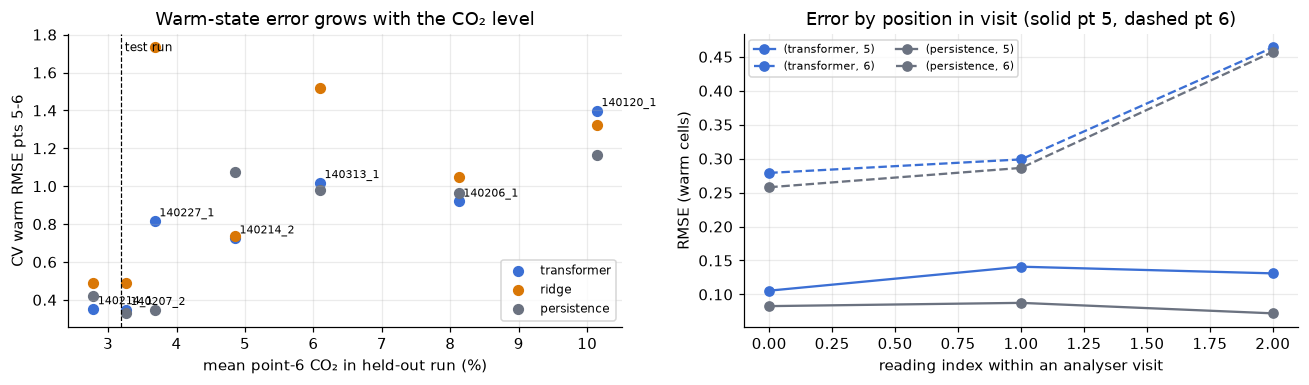

In [14]:
lvl = {r: d[d.point == 6].co2.mean() for r, d in runs.items()}
fold_err = AT.groupby(["val_run", "model"])["rmse_p56_warm"].mean().unstack()
fold_err["point-6 level"] = [lvl[r] for r in fold_err.index]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for m in ["transformer", "ridge", "persistence"]:
    ax[0].scatter(fold_err["point-6 level"], fold_err[m], label=m, color=COL[m], s=40)
for r, row in fold_err.iterrows():
    ax[0].annotate(r, (row["point-6 level"], row["transformer"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax[0].axvline(lvl[TEST_RUN], color="k", ls="--", lw=0.8); ax[0].text(lvl[TEST_RUN], ax[0].get_ylim()[1]*0.95, " test run", fontsize=8)
ax[0].set(xlabel="mean point-6 CO₂ in held-out run (%)", ylabel="CV warm RMSE pts 5-6", title="Warm-state error grows with the CO₂ level"); ax[0].legend(fontsize=8)
warm56 = c56[~cold]
pos = warm56.groupby(["point", "pos_in_visit"]).agg(transformer=("err_transformer", A.rmse),
                                                   persistence=("err_persistence", A.rmse)).unstack(0)
pos.plot(ax=ax[1], marker="o", color=[COL[m] for m in ["transformer", "persistence"] for _ in (5, 6)], style=["-", "--"] * 2)
ax[1].set(xlabel="reading index within an analyser visit", ylabel="RMSE (warm cells)", title="Error by position in visit (solid pt 5, dashed pt 6)")
ax[1].legend(fontsize=7, ncol=2); plt.tight_layout()
print(fold_err[["transformer", "ridge", "persistence", "point-6 level"]].corr()["point-6 level"].round(2))

**RC3 — even when warm, error scales with the CO₂ level.** Across the 7 CV folds, warm-state error rises with the
held-out run's point-6 level: the two highest-CO₂ runs are the hardest, and they have no comparable training run.
A distance between runs' average instrument settings did *not* predict fold error, so the problem is a shift in
the **target level**, not unusual inputs. The log-scale target (chosen in CV) is the partial fix; more high-CO₂
runs are the real one.

**RC4 — analyser dynamics.** Within a visit, later readings at point 6 are harder: the sample line is still
flushing after the switch, so readings drift. This is measurement-system behaviour the model can only partly
learn from ~120 visits.

Transformer 80% interval coverage — CV (7 runs): 0.74   test run: 0.89
Routed system 80% interval coverage on the test run: 0.90


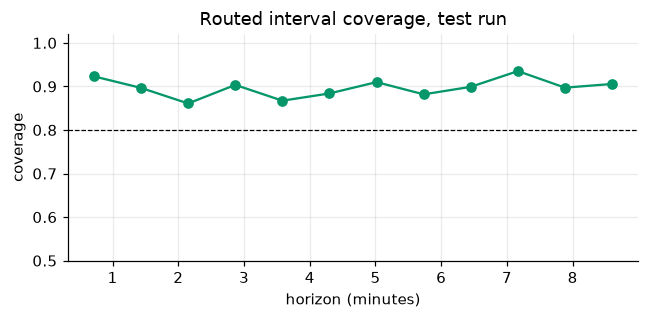

In [15]:
cov = AT[AT.model == "transformer"]
print(f"Transformer 80% interval coverage — CV (7 runs): {cov.coverage_80.mean():.2f}   test run: {RES['transformer_ensemble']['coverage_80']:.2f}")
print(f"Routed system 80% interval coverage on the test run: {RES['routed']['coverage_80']:.2f}")
cal = cells.groupby("h").covered.mean()
fig, ax = plt.subplots(figsize=(6, 3)); ax.plot(cal.index * STEP_MIN, cal.values, marker="o", color="#059669")
ax.axhline(0.8, color="k", ls="--", lw=0.8); ax.set(ylim=(0.5, 1.02), xlabel="horizon (minutes)", ylabel="coverage", title="Routed interval coverage, test run")
plt.tight_layout()

**RC5 — a calm test run.** The test run sits mid-range in CO₂ and `140207_2` was recorded the same afternoon, so
test errors are smaller than the cross-run average: compare CV and test RMSE in §0. Interval coverage is close to
nominal in CV and somewhat conservative on this calm run.

**RC6 — honest evaluation moved the numbers.** An independent review found that the first CV early-stopped on the
same run it scored, which flattered the networks against the baselines. With nested early stopping the networks'
CV error rose and persistence became the best warm-cell model (§4). That is the most important limitation of
this solution, and the reason the reference system is shown next to it in §0.

## 9. Conclusions and what I would do next

**What worked**
* Framing beats backbone: causal carry-forward state, a masked quantile loss on real readings, a residual-on-
  persistence head and a log-scale target give a Transformer that is the best single model in CV and on test.
* Slicing errors by system state (warm vs cold) turned one confusing number into two tasks, and the router uses the
  best estimator for each.
* Run-level cross-validation with nested early stopping and a paired one-SE rule kept selection honest on 898 rows.

**What limits accuracy (root causes, in order of impact)**
1. Cold start: points not yet read in a run. 2. Shift in CO₂ level between runs. 3. On points already read,
neither network beats persistence on unseen runs. 4. Within-visit analyser dynamics. 5. Only 7 training runs.

**Next steps, in order of expected value**
1. *Data, not architecture:* more runs at varied CO₂ levels; the inlet CO₂ fraction (FT302 / (FT302 + FT304)) as
   an explicit physics feature; the plant's kinetic-model output (in the original repository) as an input.
2. Choose the warm-cell estimator per deployment by CV (Transformer vs persistence) and re-test as runs accumulate.
3. Warm-start each run from the previous run's last readings (removes most cold cells in a continuous plant).
4. Train on randomly hidden points so one network covers both tasks, and compare against the router in CV.
5. Online conformal recalibration of the intervals from the `predictions` table (the API's `/monitoring`).